In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

from discodj import DiscoDJ
from discodj.cosmology.neutrinos import get_masses
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

import baccoemu

import camb
from camb import model
import classy
from scipy.optimize import fsolve
from scipy.interpolate import interp1d

jax.config.update("jax_enable_x64", False) 
import jax.numpy as jnp
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched


gpu
0.7.2


/home/raphael/venv/discodj_env/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


# COSMO

In [2]:
##### COSMOLOGY #####

def get_cosmo_params(mass):
    """This function specifies the cosmology in case of all four
    neutrino masses (0 eV, 0.15 eV, 0.3 eV, 0.6 eV)
    in terms of CLASS parameters.
    """
    # General parameters
    params = {
        'h': 0.67,
        'Omega_b': 0.049,
        'Omega_cdm': {
            0   : 0.269984542,
            0.06 : 0.2685494974,
            0.15: 0.266396931,
            0.3 : 0.269984542,
            0.6 : 0.255634096,
        }[mass],
        'T_cmb': 2.7255,
        'A_s': 2.215e-09,
        'n_s': 0.9619,
    }
    # Neutrino parameters
    N_eff = 3.046
    if mass == 0:
        params.update({
            'N_ur': N_eff,
            'N_ncdm': 0,
        })
    else:
        params.update({
            'N_ur': 0,
            'N_ncdm': 1,
            'm_ncdm': mass/3,
            'deg_ncdm': 3,
            'T_ncdm': (4/11)**(1/3)*(N_eff/3)**(1/4),
            # Precision settings
            'evolver': 0,
            'Quadrature strategy': 2,
            'Number of momentum bins': 100,
        })
    return params

params_suppl = {
    "tau": 0.0952,
    "Tcmb": 2.7255,
    "YHe": 0.24,
    "w0": -1,
    "wa": 0,
    "a": 0.5,
    "z": 1 ,
}



#Linear Suppression 
f_nu = (0.269984542-0.2685494974) / (0.049+0.269984542)
supp_P = 1-8*f_nu
supp_Pcb = 1-6*f_nu

#k scale
k_min, k_max = 5e-4, 4.9  # h/Mpc
k_h = np.logspace(np.log10(k_min), np.log10(k_max), 100)

mass = 0.3

params = get_cosmo_params(0)
params_nu = get_cosmo_params(mass)
h=params["h"]
print(params)
print(params_nu)

{'h': 0.67, 'Omega_b': 0.049, 'Omega_cdm': 0.269984542, 'T_cmb': 2.7255, 'A_s': 2.215e-09, 'n_s': 0.9619, 'N_ur': 3.046, 'N_ncdm': 0}
{'h': 0.67, 'Omega_b': 0.049, 'Omega_cdm': 0.269984542, 'T_cmb': 2.7255, 'A_s': 2.215e-09, 'n_s': 0.9619, 'N_ur': 0, 'N_ncdm': 1, 'm_ncdm': 0.09999999999999999, 'deg_ncdm': 3, 'T_ncdm': 0.7164863646133482, 'evolver': 0, 'Quadrature strategy': 2, 'Number of momentum bins': 100}


# BACCO

In [3]:
bacco_kwargs = dict(
    omega_cold=params["Omega_b"]+params["Omega_cdm"],
    omega_baryon=params["Omega_b"],
    A_s=params["A_s"],
    hubble=params["h"],
    ns=params["n_s"],
    neutrino_mass=0,
    w0=params_suppl["w0"],
    wa=params_suppl["wa"],
    expfactor=params_suppl["a"],
    k=k_h,
    cold=True,
)

mp_bacco = baccoemu.Matter_powerspectrum(
    linear=True,
    nonlinear_boost=True,
    baryonic_boost=False,
    verbose=False,
)


k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)

pk_ref = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl_ref = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))

################################################################################################

#Modify the param for the massive neutrinos


bacco_kwargs["omega_cold"] = params_nu["Omega_b"] + params_nu["Omega_cdm"]
bacco_kwargs["neutrino_mass"] = mass


k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)

pk_lin = np.exp(interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))
pk_nl = np.exp(interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h)))


    


# CLASS

In [4]:
def get_lin_power(params, z, k):
    """While params is the cosmological parameters returned
    by get_cosmo_params(), z is a single redshift while k is an
    array of k values in units of h/Mpc.
    The returned power spectrum is in units of (Mpc/h)³.
    """
    h = params['h']
    params.update({
        'output': 'mPk',
        'P_k_max_h/Mpc': np.max(k),
        'z_max_pk': z,
        'YHe' : params_suppl["YHe"],
        'tau_reio' : params_suppl["tau"],
        'T_cmb' : params_suppl["Tcmb"]

    })
    cosmo = classy.Class()
    cosmo.set(params)
    cosmo.compute()
    power = h**3*np.array([cosmo.pk_lin(h*ki, z) for ki in k])
    return power


Pkbc_CLASS = get_lin_power(params, 0, k_h)
Pkbc_CLASS_nu = get_lin_power(params_nu, 0, k_h)

# PLOTS

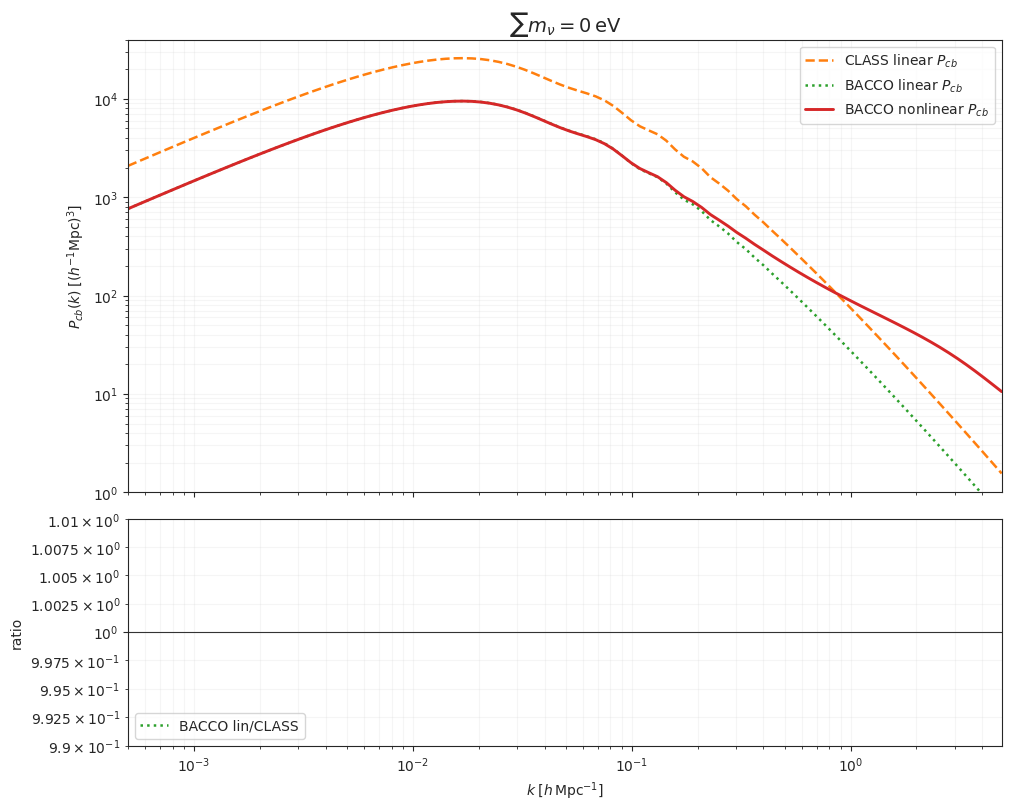

In [5]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)


ax.loglog(k_h, Pkbc_CLASS, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, pk_ref, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, pk_nl_ref, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")


ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = 0\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, pk_ref / Pkbc_CLASS, color="C2", lw=1.8, ls=":", label="BACCO lin/CLASS")


axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.99,1.01)
axr.legend(loc=3)
axr.grid(True, which="both", alpha=0.18)

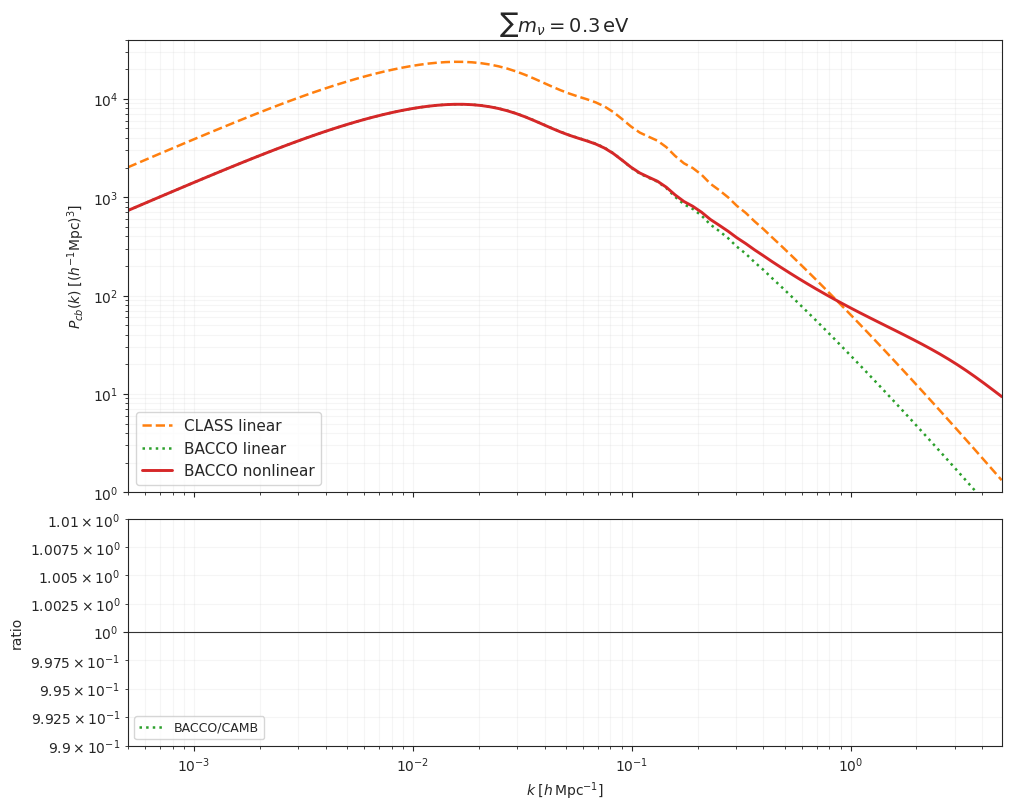

In [6]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, Pkbc_CLASS_nu, color="C1", lw=1.8, ls="--", label=r"CLASS linear")
ax.loglog(k_h, pk_lin, color="C2", lw=1.8, ls=":", label=r"BACCO linear ")
ax.loglog(k_h, pk_nl, color="C3", lw=2.1, label=r"BACCO nonlinear")


ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend(loc=3,prop={'size': 11})
ax.grid(True, which="both", alpha=0.18)
ax.set_title(rf"$\sum m_\nu = {mass}\,\mathrm{{eV}}$",fontsize=14)

axr.semilogx(k_h, pk_lin / Pkbc_CLASS_nu, color="C2", lw=1.8, ls=":", label="BACCO/CAMB")
#axr.semilogx(k_h, pk_nl / P_camb_cb_grid_nu, color="C3", lw=1.5, label="BACCO_NL/CAMB")

axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.99,1.01)
axr.legend(loc=3,prop={'size': 9},ncol=3)
axr.grid(True, which="both", alpha=0.18)
#plt.savefig('spectra_ref.pgf')

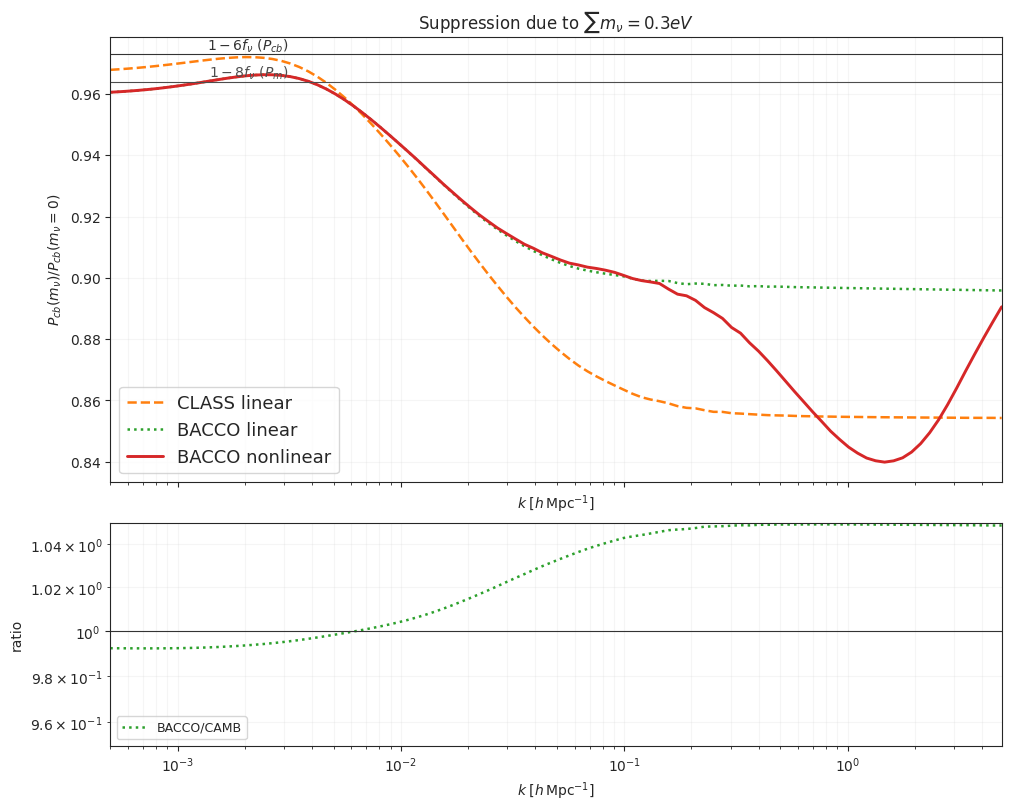

BACCO: 0.8958694960293345
CLASS: 0.8542538148697574
-0.041615681159577145


In [7]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# Ratios massive / massless
ratio_class    = Pkbc_CLASS_nu    / Pkbc_CLASS
ratio_bacco    = pk_lin           / pk_ref
ratio_bacco_nl = pk_nl            / pk_nl_ref

ax.semilogx(k_h,ratio_class,color="C1",lw=1.8,ls="--",label="CLASS linear",)
ax.semilogx(k_h,ratio_bacco,color="C2",lw=1.8,ls=":",label="BACCO linear",)
ax.semilogx(k_h,ratio_bacco_nl,color="C3",lw=2.1,label="BACCO nonlinear",)


ax.axhline(supp_Pcb, color="0.2", lw=0.8)
ax.axhline(supp_P,   color="0.3", lw=0.8)

ax.annotate(
    r"$1-6f_\nu$ ($P_{cb}$)",
    xy=(0.2, supp_Pcb),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.2",
)

ax.annotate(
    r"$1-8f_\nu$ ($P_m$)",
    xy=(0.2, supp_P),
    xycoords=("axes fraction", "data"),
    ha="right",
    va="bottom",
    color="0.3",
)

ax.set_xscale("log")
ax.set_xlim(k_h.min(), k_h.max())

ax.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$P_{cb}(m_\nu) / P_{cb}(m_\nu=0)$"
)

ax.set_title(rf"Suppression due to $\sum m_\nu = {mass}eV $")

ax.legend(prop={'size': 13})
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k_h, ratio_bacco / ratio_class, color="C2", lw=1.8, ls=":", label="BACCO/CAMB")


axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend(loc=3,prop={'size': 9},ncol=3)
axr.grid(True, which="both", alpha=0.18)


plt.show()
#plt.savefig('supp_ref_006.pgf')


print("BACCO:",ratio_bacco[-1])
print("CLASS:",ratio_class[-1])
print(ratio_class[-1]-ratio_bacco[-1])